# Phase 3: Deep Learning Spatial Modeling (Whistle-Net)
This notebook builds, trains, and evaluates a multi-input Convolutional Neural Network (CNN) to predict foul drawn probabilities based on spatial shot charts and tabular player traits.

### Methodology
- **Spatial Tensorization:** 2D histograms (20x20 grids) representing shot volume and makes.
- **Tabular Integration:** Scaled physical traits (Height, Weight, Experience, FT%).
- **Architecture:** A mid-fusion CNN that combines spatial convolutions with a dense tabular branch, outputting a predicted 20x20 foul density map.
- **Evaluation:** The residual difference between actual fouls and predicted fouls (the \"Artisan Delta\") isolates the intangible foul-drawing skill.

In [ ]:
# --- INSTALLS ---
!pip install "protobuf<4" -q

# --- CORE DATA & MATH ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import RegularPolygon, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr

# --- UTILITIES ---
import requests
from PIL import Image
from io import BytesIO
import os
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
from IPython.display import display

# --- GOOGLE CLOUD & BIGQUERY ---
from google.cloud import bigquery
from google.colab import auth

# --- DEEP LEARNING ---
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURATION & BRANDING ---
%matplotlib inline
plt.style.use('fivethirtyeight')

PROJECT_ID = os.environ.get("BQ_PROJECT_ID", "mapping-nba-fouls")
DATASET_ID = os.environ.get("BQ_DATASET_ID", "capstone_project")

BRAND_DARK = '#394146'
BRAND_WHITE = '#E6E6E6'
BRAND_GREY = '#8A8D8F'
FOUL_HIGH = '#CF142B'


print(f"🚀 Environment Ready. Libraries loaded at {datetime.now().strftime('%H:%M:%S')}")

🚀 Environment Ready. Libraries loaded at 23:30:06


In [ ]:
def draw_court_accurate(ax, color='white', lw=1.75, paint_fill_color=None):
    """Draws an accurate NBA half-court with pro markings."""
    z = 10
    if paint_fill_color:
        ax.add_patch(patches.Rectangle((-80, -52.5), 160, 190, facecolor=paint_fill_color, alpha=0.15, zorder=1))

    # Boundary and Key
    ax.add_patch(patches.Rectangle((-250, -52.5), 500, 470, linewidth=lw, color=color, fill=False, zorder=z))
    ax.plot([-250, 250], [417.5, 417.5], color=color, lw=lw, zorder=z)
    ax.add_patch(patches.Rectangle((-80, -52.5), 160, 190, linewidth=lw, color=color, fill=False, zorder=z))
    ax.add_patch(patches.Rectangle((-60, -52.5), 120, 190, linewidth=lw, color=color, fill=False, zorder=z))

    # Arcs
    ax.add_patch(patches.Arc((0, 137.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, zorder=z))
    ax.add_patch(patches.Arc((0, 137.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='dashed', zorder=z))
    ax.add_patch(patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False, zorder=z))

    # Hoop & Backboard
    ax.plot([-30, 30], [-12.5, -12.5], color=color, lw=lw*1.5, zorder=z)
    ax.add_patch(patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color, zorder=z))

    # 3PT Line
    ax.plot([-220, -220], [-52.5, 89.477], color=color, lw=lw, zorder=z)
    ax.plot([220, 220], [-52.5, 89.477], color=color, lw=lw, zorder=z)
    ax.add_patch(patches.Arc((0, 0), 475, 475, theta1=22.13, theta2=157.87, linewidth=lw, color=color, zorder=z))

    return ax

print("🏀 Court engine initialized.")

🏀 Court engine initialized.


In [ ]:
# --- 1. DATA FETCH (Lean & Pre-Engineered) ---
client = bigquery.Client(project=PROJECT_ID)

query = f"""
    SELECT
        CAST(s.player_id AS STRING) as player_id,
        p.full_name as player_name,
        s.season_id,
        s.loc_x,
        s.loc_y,
        CAST(s.is_foul_drawn AS INT64) as is_foul_drawn,
        CAST(s.is_made AS INT64) as is_made,
        p.height_inches,
        p.weight_lbs,
        p.experience_yrs, -- Using our pre-engineered feature
        CAST(p.ft_pct AS FLOAT64) as ft_pct
    FROM `{PROJECT_ID}.{DATASET_ID}.fct_shots` s
    LEFT JOIN `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` p
        ON s.player_id = p.player_id AND s.season_id = p.season_id
    WHERE s.loc_x IS NOT NULL AND s.loc_y IS NOT NULL
"""
df_raw = client.query(query).to_dataframe()

print(f"✅ Data fetched: {len(df_raw):,} rows.")

✅ Data fetched: 1,474,307 rows.


In [ ]:
# --- 2. CLEANING & FILTERING ---

# 1. First, strip the year from season_id
df_raw['season_year'] = df_raw['season_id'].astype(str).str[-4:].astype(int)

# 2. DROP NULLS: If we don't know their height, weight, or FT%, they're out.
# This prevents the model from learning "average" noise.
df_clean = df_raw.dropna(subset=['height_inches', 'weight_lbs', 'experience_yrs', 'ft_pct']).copy()

# 3. VOLUME FILTER: 65+ shots AND 65+ fouls per season
volume_stats = df_clean.groupby(['player_id', 'season_year']).agg(
    total_shots=('is_foul_drawn', 'count'),
    total_fouls=('is_foul_drawn', 'sum')
).reset_index()

valid_seasons = volume_stats[(volume_stats['total_shots'] >= 65)]

# 4. DEFINE df_filtered (The merge ensures this variable exists)
df_filtered = df_clean.merge(valid_seasons[['player_id', 'season_year']], on=['player_id', 'season_year'], how='inner')

# 5. SCALING: Identity Features (0 to 1)
scaler = MinMaxScaler()
df_filtered[['height_scaled', 'weight_scaled', 'exp_scaled']] = scaler.fit_transform(
    df_filtered[['height_inches', 'weight_lbs', 'experience_yrs']]
)

# 6. HIGH-RESOLUTION FT% SCALING
# We use the filtered population's min and max to stretch the signal
ft_min = df_filtered['ft_pct'].min()
ft_max = df_filtered['ft_pct'].max()
df_filtered['ft_pct_scaled'] = (df_filtered['ft_pct'] - ft_min) / (ft_max - ft_min)

# Update our feature list
tab_cols = ['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']

print(f"✅ Preprocessing complete. '{len(df_filtered):,}' rows remain.")
print(f"🎯 FT% Signal Stretched: {ft_min:.1%} to {ft_max:.1%}")
print(f"Tabular features ready: {tab_cols}")

✅ Preprocessing complete. '1,209,471' rows remain.
🎯 FT% Signal Stretched: 14.3% to 100.0%
Tabular features ready: ['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']


In [ ]:
# --- YEARLY POPULATION CHECK ---
# Count unique players per season in our final filtered dataset
yearly_counts = df_filtered.groupby('season_year')['player_id'].nunique().reset_index()
yearly_counts.columns = ['Season', 'Player Count']

# Sort by season to see the timeline clearly
yearly_counts = yearly_counts.sort_values('Season')

print("📊 PLAYER POPULATION (No-Null Filter Applied)")
print("-" * 45)
display(yearly_counts)

# Summary Stats
total_samples = len(df_filtered.groupby(['player_id', 'season_year']))
avg_players = yearly_counts['Player Count'].mean()

print("-" * 45)
print(f"🚀 TOTAL UNIQUE PLAYER-SEASONS: {total_samples}")
print(f"📍 Average Players per Season:   {avg_players:.1f}")

📊 UPDATED PLAYER POPULATION (No-Null Filter Applied)
---------------------------------------------


,Season,Player Count
0,2019,344
1,2020,359
2,2021,369
3,2022,356
4,2023,360
5,2024,381


---------------------------------------------
🚀 TOTAL UNIQUE PLAYER-SEASONS: 2169
📍 Average Players per Season:   361.5


In [ ]:
# --- 3. TENSORIZATION ---
grid_size = 20
extent = [-250, 250, -52.5, 417.5]
groups = df_filtered.groupby(['player_id', 'season_year'])

spatial_in, tabular_in, targets = [], [], []

print(f"📦 Packaging {len(groups)} high-quality player-seasons...")

for (pid, year), group in groups:
    # Spatial Channels
    shots, _, _ = np.histogram2d(group['loc_x'], group['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    makes, _, _ = np.histogram2d(group[group['is_made']==1]['loc_x'], group[group['is_made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    # Target (Actual Fouls)
    fouls, _, _ = np.histogram2d(group[group['is_foul_drawn']==1]['loc_x'], group[group['is_foul_drawn']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])

    spatial_in.append(np.stack([shots, makes], axis=-1))
    # We pull from tab_cols which now includes 'ft_pct_scaled'
    tabular_in.append(group[tab_cols].iloc[0].values.astype(float))
    targets.append(np.expand_dims(fouls, -1))

X_spatial = np.array(spatial_in)
X_tab = np.array(tabular_in)
y_foul_map = np.array(targets)

# Maintain global scaling consistency
GLOBAL_SHOT_MAX = np.max(X_spatial[:,:,:,0])
X_spatial_scaled = X_spatial / GLOBAL_SHOT_MAX

# Train/Test Split (85/15)
X_sp_train, X_sp_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_spatial_scaled, X_tab, y_foul_map, test_size=0.15, random_state=42
)

print("-" * 30)
print(f"✅ Tensors Built with Stretched FT Signal")
print(f"Final Training Samples: {len(X_sp_train)}")

📦 Packaging 2169 high-quality player-seasons...
------------------------------
✅ Tensors Built with Stretched FT Signal
Final Training Samples: 1843


In [ ]:
print(f"📊 Global Shot Max (Normalization Factor): {GLOBAL_SHOT_MAX}")

📊 Global Shot Max (Normalization Factor): 364.0


In [ ]:
def build_whistle_net(spatial_shape=(20, 20, 2), tabular_shape=(4,)):
    # --- BRANCH A: SPATIAL (The "Where") ---
    spatial_in = Input(shape=spatial_shape, name="Shot_Chart_Input")

    # Layer 1: Local clusters
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(spatial_in)
    x = layers.BatchNormalization()(x)

    # Layer 2: Spatial relationships
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Layer 3: High-level features
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Spatial summary vector
    spatial_features = layers.GlobalMaxPooling2D()(x)

    # --- BRANCH B: TABULAR (The "Who") ---
    tabular_in = Input(shape=tabular_shape, name="Player_Traits_Input")
    y = layers.Dense(16, activation='relu')(tabular_in)
    y = layers.BatchNormalization()(y)

    # --- THE MERGE (Mid-Fusion) ---
    merged = layers.Concatenate()([spatial_features, y])

    # Decision Head
    z = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(merged)
    z = layers.Dropout(0.4)(z)

    # Output: 400 hexes (20x20)
    z = layers.Dense(20 * 20, activation='softplus')(z)

    output = layers.Reshape((20, 20, 1), name="Foul_Heatmap")(z)

    model = models.Model(inputs=[spatial_in, tabular_in], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008), loss='poisson')

    return model

print("🏗️ Model architecture 'build_whistle_net' is now defined and ready.")


🏗️ Model architecture 'build_whistle_net_v3_5' is now defined and ready.


In [ ]:
import tensorflow as tf

# --- CALLBACK DEFINITION ---
callbacks = [
    # 1. Stop if val_loss doesn't improve for 15 epochs (Prevents overfitting)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # 2. Cut learning rate by half if we plateau for 8 epochs
    # This helps the model "fine-tune" the weights for those tricky role players
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ Callbacks defined. Ready to train.")

# --- NOW RE-RUN TRAINING ---
foul_model = build_whistle_net(tabular_shape=(4,))

history = foul_model.fit(
    x=[X_sp_train, X_tab_train],
    y=y_train,
    validation_data=([X_sp_test, X_tab_test], y_test),
    epochs=120,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

✅ Callbacks defined. Ready to train V3.8.
Epoch 1/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.2900 - val_loss: 0.1729 - learning_rate: 8.0000e-04
Epoch 2/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1297 - val_loss: 0.1427 - learning_rate: 8.0000e-04
Epoch 3/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1046 - val_loss: 0.1295 - learning_rate: 8.0000e-04
Epoch 4/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0956 - val_loss: 0.1183 - learning_rate: 8.0000e-04
Epoch 5/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0912 - val_loss: 0.0942 - learning_rate: 8.0000e-04
Epoch 6/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0886 - val_loss: 0.1029 - learning_rate: 8.0000e-04
Epoch 7/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0869 - val_loss: 0.1025 - learning_rate: 8.0000e-04
Epoch 8/120
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0864 - val_loss: 0.0839 - learning_rate: 8.0000e-04
Epoch 9/120
116/116 ━━━━━━━━━━

In [ ]:
import numpy as np
from scipy.stats import pearsonr

# 1. Generate Predictions for the Test Set
y_pred = foul_model.predict([X_sp_test, X_tab_test], verbose=0)

# 2. Season Volume MAE & Global Bias
# Flatten the 20x20 grids into total foul counts per player-season
actual_totals = np.sum(y_test, axis=(1, 2, 3))
pred_totals = np.sum(y_pred, axis=(1, 2, 3))

mae_total = np.mean(np.abs(actual_totals - pred_totals))
bias = np.sum(actual_totals) / np.sum(pred_totals)

# 3. Spatial Correlation (Heatmap Accuracy)
# Calculate how well the predicted 'hot spots' match the actual 'hot spots'
corrs = []
for i in range(len(y_test)):
    # Flatten 20x20 grid to 400 points
    a = y_test[i].flatten()
    p = y_pred[i].flatten()

    # Only calculate correlation if there is variation in the data (avoiding div by zero)
    if np.std(a) > 0 and np.std(p) > 0:
        corr, _ = pearsonr(a, p)
        corrs.append(corr)

avg_corr = np.mean(corrs) if corrs else 0.0

# 4. Print the Final Audit
print("-" * 30)
print(f"📊 LEAGUE BASELINE AUDIT")
print("-" * 30)
print(f"Poisson Loss (Val):   {history.history['val_loss'][-1]:.4f}")
print(f"Spatial Correlation:  {avg_corr:.2%}")
print(f"Season Volume MAE:    {mae_total:.2f} fouls")
print(f"Global Bias Factor:   {bias:.2f}x")
print("-" * 30)

------------------------------
📊 V3.8 LEAGUE BASELINE AUDIT
------------------------------
Poisson Loss (Val):   0.0768
Spatial Correlation:  83.10%
Season Volume MAE:    10.54 fouls
Global Bias Factor:   1.00x
------------------------------


In [ ]:
# --- 5. EVALUATION: THE ARTISAN BENCHMARK ---
# 1. Generate Predictions for the test set
y_pred = foul_model.predict([X_sp_test, X_tab_test])

# 2. Calculate MAE for the Test Set (League-wide)
# Rescale back from the 20x20 density to raw foul counts
actual_total = np.sum(y_test, axis=(1, 2, 3))
pred_total = np.sum(y_pred, axis=(1, 2, 3))
mae_league = np.mean(np.abs(actual_total - pred_total))

print(f"📉 League-Wide MAE: {mae_league:.2f}")

# 3. IDENTIFY THE "SIGNATURE" LEADERS
# We'll run all 2,169 player-seasons through the model to see who breaks the baseline
all_preds = foul_model.predict([X_spatial_scaled, X_tab])
all_actuals = np.sum(y_foul_map, axis=(1, 2, 3))
all_predicted_totals = np.sum(all_preds, axis=(1, 2, 3))

# Create a Results DataFrame
results_artisan = []
for i, (pid, year) in enumerate(groups.groups.keys()):
    results_artisan.append({
        'player_id': pid,
        'season': year,
        'actual_fouls': all_actuals[i],
        'expected_fouls': all_predicted_totals[i],
        'signature_delta': all_actuals[i] - all_predicted_totals[i]
    })

df_results = pd.DataFrame(results_artisan)

# Map names back for the leaderboard
name_map = df_filtered.set_index('player_id')['player_name'].to_dict()
df_results['player_name'] = df_results['player_id'].map(name_map)

print("\n🏆 TOP SIGNATURE WHISTLES (League Baseline)")
print("-" * 50)
display(df_results.sort_values('signature_delta', ascending=False).head(10))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
📉 League-Wide MAE (V3.8): 10.54
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

🏆 TOP SIGNATURE WHISTLES (V3.8 - League Baseline)
--------------------------------------------------


,player_id,season,actual_fouls,expected_fouls,signature_delta,player_name
1009,1630183,2022,131.0,77.034698,53.965302,Jaden McDaniels
307,1628370,2024,110.0,66.759842,43.240158,Malik Monk
556,1628991,2024,138.0,95.306366,42.693634,Jaren Jackson Jr.
346,1628381,2022,150.0,107.402756,42.597244,John Collins
2080,203939,2022,138.0,96.525070,41.474930,Dwight Powell
1935,203482,2023,109.0,71.692291,37.307709,Kelly Olynyk
247,1627777,2023,114.0,78.350494,35.649506,Georges Niang
838,1629655,2023,159.0,123.954414,35.045586,Daniel Gafford
948,1630168,2022,163.0,129.551834,33.448166,Onyeka Okongwu
1290,1631099,2023,113.0,79.869339,33.130661,Keegan Murray


In [ ]:
# --- 2024 SEASON SIGNATURE LEADERS ---
# Filter for 2024 and sort by Delta
top_15_2024 = df_results[df_results['season'] == 2024].sort_values('signature_delta', ascending=False).head(15)

print("🏆 2024 FOUL SIGNATURE DELTA: THE ELITE ARTISANS")
print("-" * 75)
display(top_15_2024[['player_name', 'actual_fouls', 'expected_fouls', 'signature_delta']])

🏆 2024 FOUL SIGNATURE DELTA: THE ELITE ARTISANS
---------------------------------------------------------------------------


,player_name,actual_fouls,expected_fouls,signature_delta
307,Malik Monk,110.0,66.759842,43.240158
556,Jaren Jackson Jr.,138.0,95.306366,42.693634
1306,Jalen Duren,148.0,119.573227,28.426773
1463,Bub Carrington,116.0,88.892784,27.107216
1948,Mason Plumlee,97.0,72.439865,24.560135
886,Jordan Poole,84.0,61.355621,22.644379
424,Dillon Brooks,105.0,82.646515,22.353485
1469,Kyshawn George,119.0,96.832260,22.167740
248,Georges Niang,97.0,76.556793,20.443207
1291,Keegan Murray,104.0,83.722389,20.277611


In [ ]:
def final_optimization_blueprint(player_id, year, model, df_source):
    client = bigquery.Client(project=PROJECT_ID)
    target_sid = f"2{year}"
    season_title = f"{year-1}-{str(year)[-2:]}"

    # --- 1. DATA FETCH ---
    q_s = f"""SELECT loc_x, loc_y, team_id, CAST(is_foul_drawn AS INT64) as foul,
              CAST(is_made AS INT64) as made FROM `{PROJECT_ID}.{DATASET_ID}.fct_shots`
              WHERE player_id = '{player_id}' AND season_id = '{target_sid}'"""
    df_s = client.query(q_s).to_dataframe()
    if df_s.empty: return

    q_f = f"SELECT loc_x, loc_y FROM `{PROJECT_ID}.{DATASET_ID}.fct_fouls` WHERE player_id = '{player_id}' AND season_id = '{target_sid}'"
    df_f = client.query(q_f).to_dataframe()

    p_name, t_abbr, primary, secondary = "Unknown Player", "NBA", BRAND_GREY, FOUL_HIGH
    try:
        p_name = client.query(f"SELECT full_name FROM `{PROJECT_ID}.{DATASET_ID}.dim_player_seasons` WHERE player_id = '{player_id}' LIMIT 1").to_dataframe().iloc[0]['full_name']
        t_id_str = str(int(df_s['team_id'].dropna().iloc[0]))
        c_df = client.query(f"SELECT team_abbr, primary_color, secondary_color FROM `{PROJECT_ID}.{DATASET_ID}.dim_teams` WHERE team_id = '{t_id_str}'").to_dataframe()
        if not c_df.empty: t_abbr, primary, secondary = c_df.iloc[0]['team_abbr'], c_df.iloc[0]['primary_color'], c_df.iloc[0]['secondary_color']
    except: pass

    # --- 2. FEATURE & FT% LOGIC ---
    clean_df = df_source.reset_index().loc[:, ~df_source.reset_index().columns.duplicated()].copy()
    target_sid_int = int(target_sid)
    player_row = clean_df[(clean_df['player_id'] == player_id) & (clean_df['season_id'] == target_sid_int)]

    ft_pct = 0.77
    tab_in = np.array([0.5, 0.5, 0.5, 0.5])

    if not player_row.empty:
        tab_in = player_row[['height_scaled', 'weight_scaled', 'exp_scaled', 'ft_pct_scaled']].iloc[0].values.astype(float)
        ft_pct = player_row['ft_pct'].iloc[0]

    # --- 3. SPATIAL GRIDDING ---
    extent = [-250, 250, -52.5, 417.5]; grid_size = 20
    counts, x_edges, y_edges = np.histogram2d(df_s['loc_x'], df_s['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    made_grid, _, _ = np.histogram2d(df_s[df_s['made']==1]['loc_x'], df_s[df_s['made']==1]['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]])
    foul_grid, _, _ = np.histogram2d(df_s['loc_x'], df_s['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]], weights=df_s['foul'])
    actual_pts_sum, _, _ = np.histogram2d(df_s['loc_x'], df_s['loc_y'], bins=grid_size, range=[extent[:2], extent[2:]],
                                          weights=np.where(df_s['foul'] == 1, 2 * ft_pct, df_s['made'] * 2))

    # --- 4. PREDICTION (Baseline) ---
    norm_val = 364.0
    spatial_input = np.expand_dims(np.stack([counts, made_grid], axis=-1) / norm_val, 0)
    pred_foul_counts = model.predict([spatial_input, np.expand_dims(tab_in, 0)], verbose=0)[0].reshape(20, 20)

    with np.errstate(divide='ignore', invalid='ignore'):
        ppa_grid = actual_pts_sum / counts
        delta_ppa_grid = ((foul_grid - pred_foul_counts) * 2 * ft_pct) / counts

    # --- 5. BINNING LOGIC (The "5-Size" Restoration) ---
    temp_fig = plt.figure(); hb = plt.hexbin(df_s['loc_x'], df_s['loc_y'], gridsize=grid_size, extent=extent); verts = hb.get_offsets(); plt.close(temp_fig)
    v_df = pd.DataFrame([{'v': v, 'n': counts[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)],
                          'ppa': ppa_grid[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)],
                          'delta': delta_ppa_grid[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)]}
                         for v in verts if counts[np.clip(np.digitize(v[0], x_edges)-1, 0, 19), np.clip(np.digitize(v[1], y_edges)-1, 0, 19)] >= 3])

    # YOUR ORIGINAL BINNING LOGIC RESTORED
    bins = sorted(list(set([2, max(3, np.percentile(v_df['n'], 25)), max(4, v_df['n'].median()),
                            max(5, np.percentile(v_df['n'], 75)), max(6, np.percentile(v_df['n'], 90)), v_df['n'].max()])))
    v_df['size_rank'] = pd.cut(v_df['n'], bins=bins, labels=False, include_lowest=True) + 1

    # --- 6. RENDER DASHBOARD ---
    fig = plt.figure(figsize=(14, 11), facecolor=BRAND_DARK)
    fig.text(0.02, 0.97, "CRITICAL SECTION // OPTIMIZATION BLUEPRINT", color=BRAND_WHITE, fontsize=28, fontweight='bold', va='top')
    fig.text(0.02, 0.935, f"{p_name.upper()} // {t_abbr} // {season_title} SCORING ECONOMY", color=BRAND_GREY, fontsize=14, va='top')

    ax_court = fig.add_axes([0.0, 0.07, 0.69, 0.9])
    ax_court.set_facecolor(BRAND_DARK); ax_court.set_aspect('equal'); ax_court.set_xlim(-260, 260); ax_court.set_ylim(-65, 480); ax_court.axis('off')

    div_cmap = plt.cm.RdBu_r; MAX_R = 25.0 / np.sqrt(3)
    for _, row in v_df.iterrows():
        rad = (0.08 + 0.82 * (row['size_rank'] / len(bins[:-1]))) * MAX_R
        ax_court.add_patch(RegularPolygon(row['v'], 6, radius=rad, facecolor=div_cmap(np.clip((row['ppa']-0.6)/0.96, 0, 1)),
                                         edgecolor=div_cmap(np.clip((row['delta']+0.15)/0.3, 0, 1)), linewidth=2.5, alpha=0.95, zorder=3))

    if not df_f.empty:
        fcnts, xedges_f, yedges_f = np.histogram2d(df_f['loc_x'], df_f['loc_y'], bins=40, range=[[-250, 250], [-52.5, 417.5]])
        smoothed = gaussian_filter(fcnts, sigma=1.5)
        X, Y = np.meshgrid(np.linspace(-250, 250, 40), np.linspace(-52.5, 417.5, 40))
        ax_court.contour(X, Y, smoothed.T, levels=np.percentile(smoothed[smoothed>0], [75, 90, 98]), colors=secondary, linewidths=0.75, alpha=0.8, zorder=6)

    draw_court_accurate(ax_court, color=primary, lw=2.0, paint_fill_color=primary)

    # UI PANELS (RESTORED)
    ax_stats = fig.add_axes([0.71, 0.62, 0.2, 0.18])
    ax_stats.set_facecolor(BRAND_DARK); ax_stats.axis('off'); ax_stats.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor=secondary, lw=1.5, transform=ax_stats.transAxes))
    ax_stats.text(0.5, 0.85, "OPTIMIZATION STATS", color=BRAND_WHITE, fontsize=12, weight='bold', ha='center', transform=ax_stats.transAxes)
    ax_stats.text(0.05, 0.60, f"Total Shots Map: {int(v_df['n'].sum()):,}", color=BRAND_WHITE, transform=ax_stats.transAxes)
    ax_stats.text(0.05, 0.40, f"Avg PPA: {actual_pts_sum.sum()/counts.sum():.2f}", color=BRAND_WHITE, transform=ax_stats.transAxes)
    ax_stats.text(0.05, 0.05, "Contours: Foul Density Overlay", color=secondary, style='italic', transform=ax_stats.transAxes)

    ax_leg = fig.add_axes([0.68, 0.21, 0.25, 0.36])
    ax_leg.set_facecolor(BRAND_DARK); ax_leg.set_aspect('equal'); ax_leg.axis('off'); ax_leg.set_xlim(0, 150); ax_leg.set_ylim(0, 200)
    ax_leg.add_patch(Rectangle((0, 5), 150, 195, fill=False, edgecolor=secondary, lw=1.5))
    ax_leg.text(75, 185, "SHOT VOLUME", color=BRAND_WHITE, weight='bold', size=11, ha='center')

    q_stats = v_df.groupby('size_rank')['n'].agg(['min', 'max']).sort_index()
    num_bins = len(bins[:-1])
    y_sp = 135 / max(1, (num_bins-1))
    for i, rank in enumerate(q_stats.index):
        label = f"{int(q_stats.loc[rank]['min'])}-{int(q_stats.loc[rank]['max'])} shots"
        if i == num_bins - 1: label = f"{int(q_stats.loc[rank]['min'])}+ shots"
        ax_leg.add_patch(RegularPolygon((45, 150-i*y_sp+15), 6, radius=(0.08+0.82*(rank/num_bins))*MAX_R, facecolor=secondary, edgecolor=primary, linewidth=2.0))
        ax_leg.text(80, 150-i*y_sp+15, label, color=BRAND_WHITE, size=11)

    try:
        img = Image.open(BytesIO(requests.get(f"https://cdn.nba.com/headshots/nba/latest/1040x760/{player_id}.png").content)).convert("RGBA")
        ax_photo = fig.add_axes([0.65, 0.0, 0.32, 0.20]); ax_photo.axis('off'); ax_photo.imshow(img, aspect='equal')
    except: pass

    for i, (lab, n_range) in enumerate([('HEX FILL: TOTAL EFFICIENCY (PPA)', (0.6, 1.5)), ('HEX BORDER: FOUL SIGNATURE DELTA', (-0.15, 0.15))]):
        cb_ax = fig.add_axes([0.02 + i*0.32, 0.02, 0.28, 0.015])
        fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(*n_range), cmap=div_cmap), cax=cb_ax, orientation='horizontal')
        cb_ax.set_xlabel(lab, color=BRAND_WHITE, size=10, weight='bold')

    plt.show()

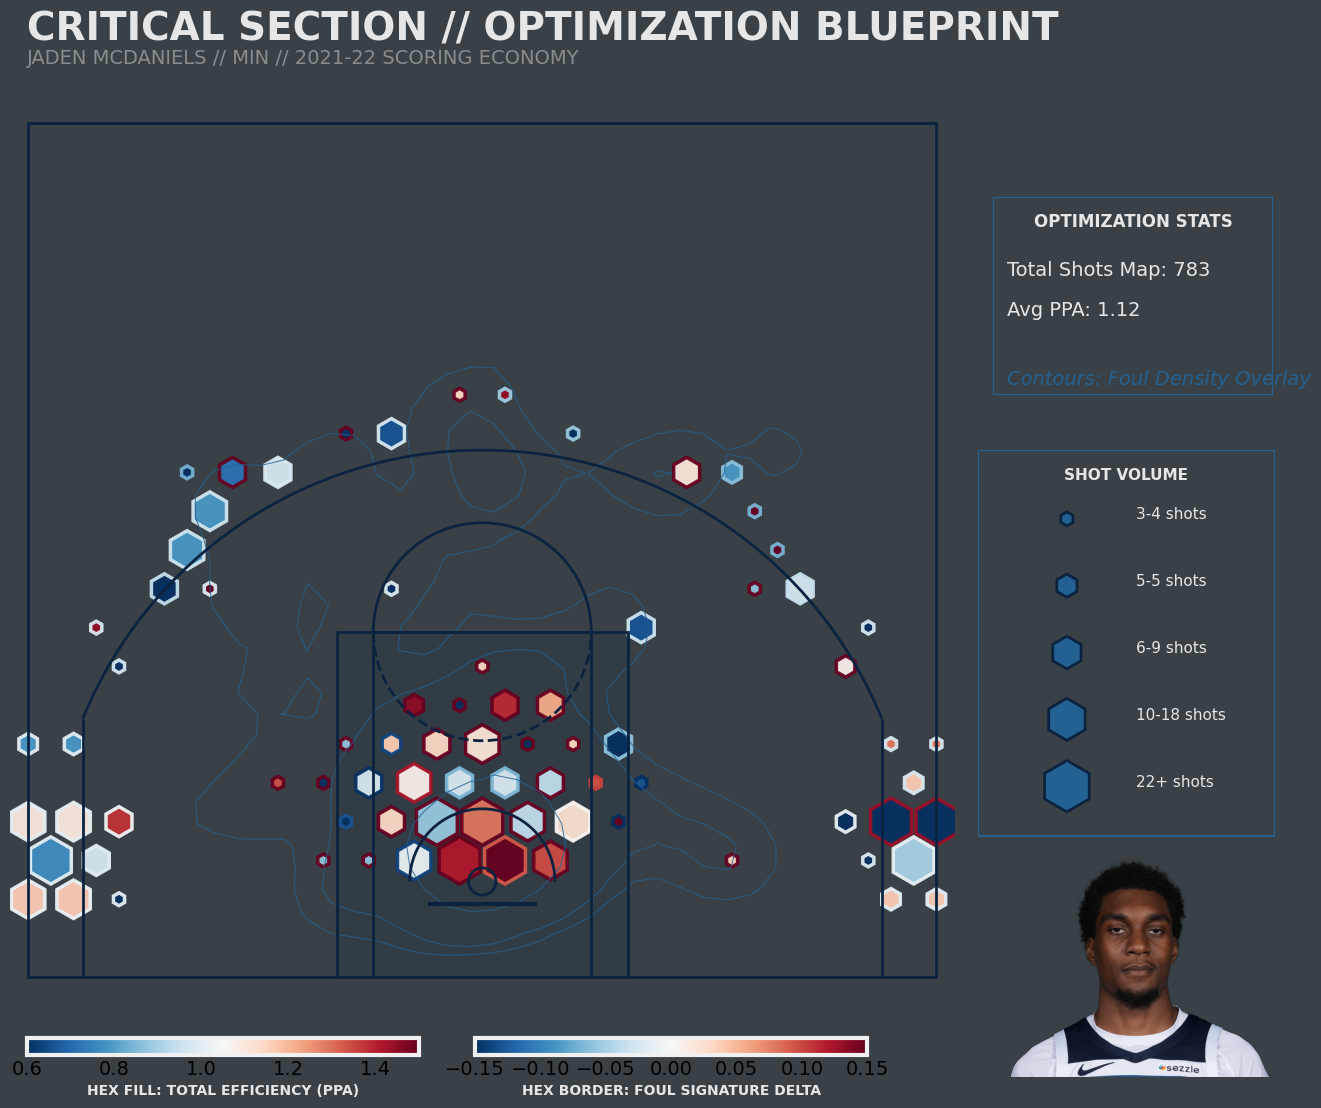

In [ ]:
# View the surprise leader with ALL visual elements restored
final_optimization_blueprint(player_id="1630183", year=2022, model=foul_model, df_source=df_filtered)

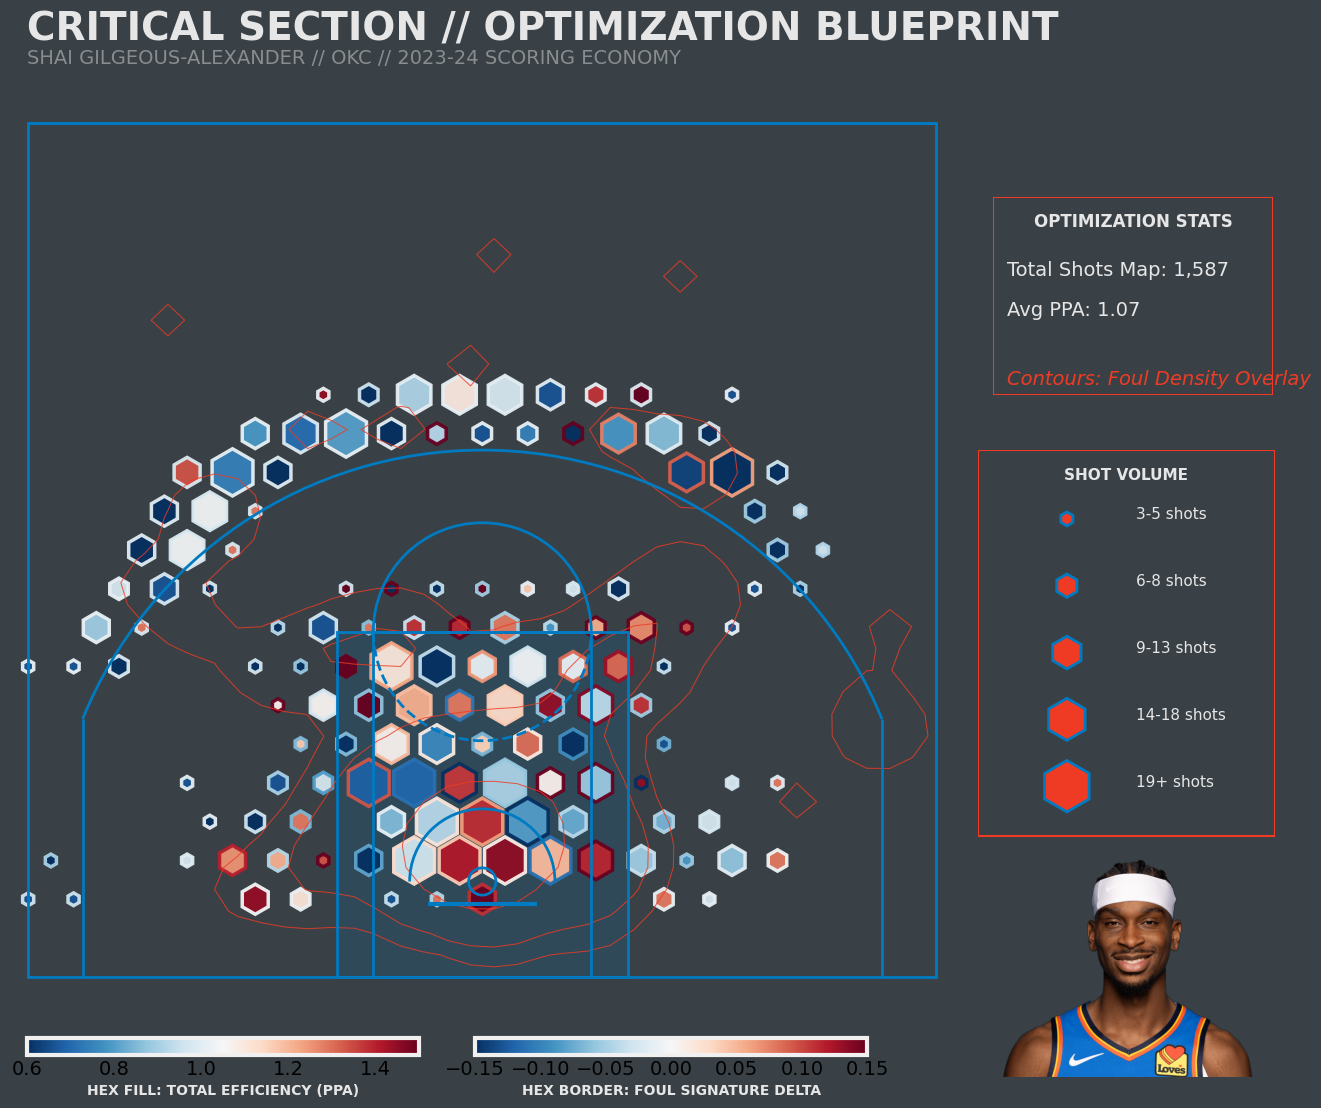

In [ ]:
# --- RUNNING THE BLUEPRINT FOR SGA 2023-24 (Shai Gilgeous-Alexander) ---
# player_id: 1628983 (Shai Gilgeous-Alexander)
# year: 2024 (represents the 2023-24 season)

final_optimization_blueprint(
    player_id="1628983",
    year=2024,
    model=foul_model,
    df_source=df_filtered
)

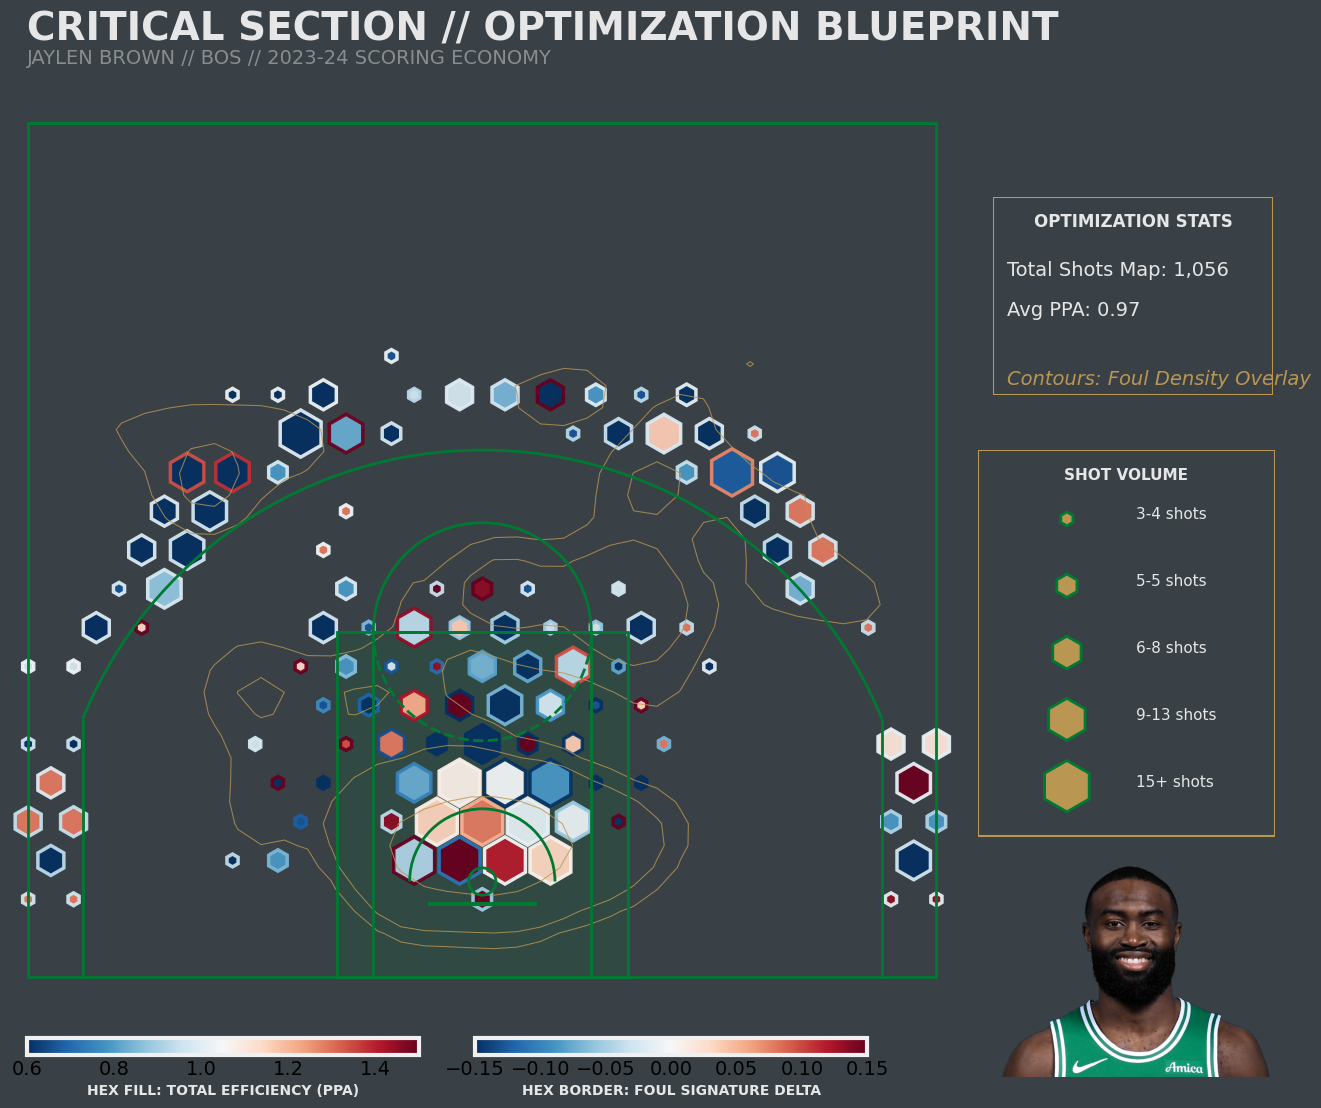

In [ ]:
# --- RUNNING THE BLUEPRINT FOR JAYLEN BROWN 2023-24 (Jaylen Brown) ---
# player_id: 1627759 (Jaylen Brown)
# year: 2024 (represents the 2023-24 season)

final_optimization_blueprint(
    player_id="1627759",
    year=2024,
    model=foul_model,
    df_source=df_filtered
)

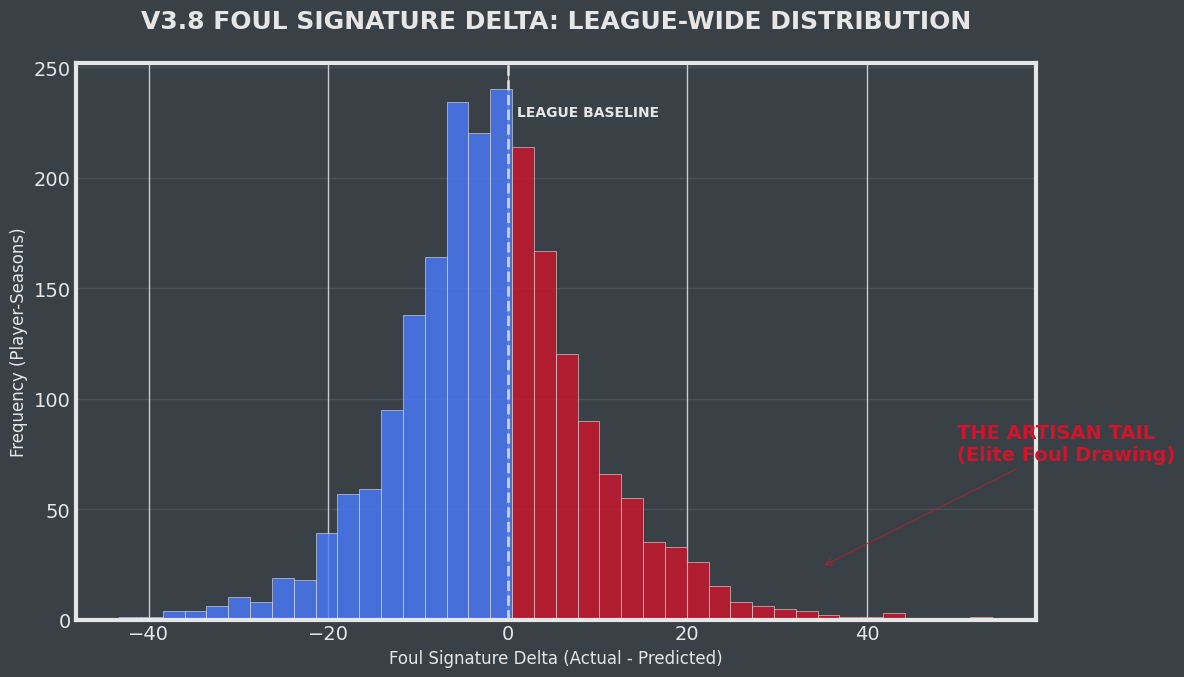

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. SETUP THE BRANDED CANVAS
fig, ax = plt.subplots(figsize=(12, 7), facecolor=BRAND_DARK)
ax.set_facecolor(BRAND_DARK)

# 2. PLOT THE DATA
deltas = df_results['signature_delta']
# Using 40 bins to catch the "Artisan Tails"
n, bins, patches = ax.hist(deltas, bins=40, color=BRAND_GREY, alpha=0.8, edgecolor=BRAND_WHITE, linewidth=0.5)

# Colorize: Red for Artisans (Positive Delta), Blue for Efficient Finishers (Negative Delta)
for bin_value, patch in zip(bins, patches):
    if bin_value > 0:
        patch.set_facecolor(FOUL_HIGH) # Our 'Surprise' color
    else:
        patch.set_facecolor('#4B7BFF') # Standard Efficiency

# 3. ADD BASELINE & ANNOTATIONS
ax.axvline(0, color=BRAND_WHITE, linestyle='--', linewidth=2, alpha=0.8)
ax.text(1, n.max()*0.95, "LEAGUE BASELINE", color=BRAND_WHITE, fontweight='bold', fontsize=10)

# Statistical Markers
mean_val = deltas.mean()
ax.annotate('THE ARTISAN TAIL\n(Elite Foul Drawing)', xy=(35, n.max()*0.1), xytext=(50, n.max()*0.3),
            color=FOUL_HIGH, weight='bold', arrowprops=dict(arrowstyle='->', color=FOUL_HIGH))

# 4. FORMATTING
ax.set_title("FOUL SIGNATURE DELTA: LEAGUE-WIDE DISTRIBUTION", color=BRAND_WHITE, fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Foul Signature Delta (Actual - Predicted)", color=BRAND_WHITE, fontsize=12)
ax.set_ylabel("Frequency (Player-Seasons)", color=BRAND_WHITE, fontsize=12)
ax.tick_params(colors=BRAND_WHITE)
for spine in ax.spines.values(): spine.set_color(BRAND_WHITE)
ax.grid(axis='y', alpha=0.1, color=BRAND_WHITE)

plt.tight_layout()
plt.show()

In [ ]:
# --- THE ALL-TIME ARTISAN LEADERBOARD ---
# 1. Group by player and average their signature delta
career_signatures = df_results.groupby('player_name').agg({
    'signature_delta': 'mean',
    'actual_fouls': 'sum',
    'expected_fouls': 'sum',
    'season': 'count' # Number of seasons in the dataset
}).rename(columns={'season': 'seasons_analyzed'})

# 2. Filter for players with at least 2 seasons to ensure consistency
consistent_artisans = career_signatures[career_signatures['seasons_analyzed'] >= 2]

# 3. Display the Top 15 All-Time Leaders
top_career_artisans = consistent_artisans.sort_values('signature_delta', ascending=False).head(15)

print("🏀 THE ALL-TIME WHISTLE-NET ELITE (AVERAGE DELTA)")
print("-" * 75)
display(top_career_artisans[['signature_delta', 'seasons_analyzed', 'actual_fouls', 'expected_fouls']])

🏀 THE ALL-TIME WHISTLE-NET ELITE (AVERAGE DELTA)
---------------------------------------------------------------------------


,signature_delta,seasons_analyzed,actual_fouls,expected_fouls
player_name,,,,
Jaden McDaniels,24.920811,5,571.0,446.395935
Keegan Murray,22.397364,3,329.0,261.807922
Kelly Olynyk,20.739724,6,521.0,396.561646
Onyeka Okongwu,19.248987,5,546.0,449.755066
Jabari Smith Jr.,15.904719,3,316.0,268.285828
Daniel Gafford,15.363192,6,608.0,515.820862
Aaron Nesmith,15.006330,5,426.0,350.968353
John Collins,14.857388,6,595.0,505.855682
Cason Wallace,14.029461,2,152.0,123.941078


In [ ]:
import pandas as pd
import numpy as np

def build_full_attribution_table(model, X_sp, X_tb, y_map, group_keys):
    # 1. SETUP NEUTRAL BASELINE (The "Average Human" profile)
    # We use 0.5 because your data is MinMaxScaler-scaled to [0,1]
    neutral_tab = np.full_like(X_tb, 0.5)

    # 2. RUN BULK PREDICTIONS
    print(f"🧬 Deconstructing DNA for {len(X_sp)} player-seasons...")

    # Final prediction: Full model (Where + Who)
    pred_final = model.predict([X_sp, X_tb], verbose=0).sum(axis=(1,2,3))

    # Geography-only prediction: (Where + Neutral Who)
    pred_geo = model.predict([X_sp, neutral_tab], verbose=0).sum(axis=(1,2,3))

    # Actual observed fouls
    actual_totals = y_map.sum(axis=(1,2,3))

    # 3. ASSEMBLE DATASET
    attribution_data = []

    # Iterate through the groups to align metadata with predictions
    for i, (player_id, season_year) in enumerate(group_keys):
        # Calculate the three specific buckets
        geo_val = pred_geo[i]
        profile_val = pred_final[i] - pred_geo[i]
        artisan_val = actual_totals[i] - pred_final[i]

        attribution_data.append({
            'player_id': player_id,
            'season': season_year,
            'actual_fouls': actual_totals[i],
            'geography_effect': geo_val,
            'profile_boost': profile_val,
            'artisan_residual': artisan_val,
            'total_predicted': pred_final[i]
        })

    # 4. FINAL CLEANUP & MAPPING
    df_dna = pd.DataFrame(attribution_data)

    # Map names back from your original df_filtered
    name_map = df_filtered.set_index('player_id')['player_name'].to_dict()
    df_dna['player_name'] = df_dna['player_id'].map(name_map)

    # Contextual Percentages
    df_dna['geo_reliance_pct'] = (df_dna['geography_effect'] / df_dna['total_predicted']) * 100

    return df_dna

# --- EXECUTION ---
# Using the metadata keys from your 'groups' object to ensure perfect alignment
player_season_keys = list(groups.groups.keys())

df_whistle_dna = build_full_attribution_table(
    foul_model,
    X_spatial_scaled,
    X_tab,
    y_foul_map,
    player_season_keys
)

# Display the top 'Artisan' signatures (unexplained by size or location)
print("\n🏆 TOP 15 PLAYER-SEASONS BY ARTISAN RESIDUAL (SKILL)")
display(df_whistle_dna.sort_values('artisan_residual', ascending=False).head(15))

🧬 Deconstructing DNA for 2169 player-seasons...

🏆 TOP 15 PLAYER-SEASONS BY ARTISAN RESIDUAL (SKILL)


,player_id,season,actual_fouls,geography_effect,profile_boost,artisan_residual,total_predicted,player_name,geo_reliance_pct
1009,1630183,2022,131.0,73.930626,3.104073,53.965302,77.034698,Jaden McDaniels,95.970551
307,1628370,2024,110.0,70.252716,-3.492874,43.240158,66.759842,Malik Monk,105.232002
556,1628991,2024,138.0,87.066704,8.239662,42.693634,95.306366,Jaren Jackson Jr.,91.354553
346,1628381,2022,150.0,101.804306,5.598450,42.597244,107.402756,John Collins,94.787422
2080,203939,2022,138.0,89.757149,6.767921,41.474930,96.525070,Dwight Powell,92.988434
1935,203482,2023,109.0,63.354671,8.337620,37.307709,71.692291,Kelly Olynyk,88.370270
247,1627777,2023,114.0,76.101807,2.248688,35.649506,78.350494,Georges Niang,97.129967
838,1629655,2023,159.0,117.517540,6.436874,35.045586,123.954414,Daniel Gafford,94.807068
948,1630168,2022,163.0,124.175995,5.375839,33.448166,129.551834,Onyeka Okongwu,95.850433
1290,1631099,2023,113.0,77.316620,2.552719,33.130661,79.869339,Keegan Murray,96.803879


In [ ]:
# Updated Configuration for Oregon
REGION = "us-west1"
BUCKET_NAME = f"{PROJECT_ID}-artifacts"

# Create the bucket using the gsutil tool
!gsutil mb -l {REGION} gs://{BUCKET_NAME}

print(f"✅ Bucket 'gs://{BUCKET_NAME}' created in {REGION}.")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Creating gs://mapping-nba-fouls-artifacts/...
✅ Bucket 'gs://mapping-nba-fouls-artifacts' created in us-west1.


In [ ]:
# Updated Save Logic for Keras 3
MODEL_GCS_PATH = f"gs://{BUCKET_NAME}/whistle_net.keras"
foul_model.save(MODEL_GCS_PATH)

print(f"✅ Model successfully saved to: {MODEL_GCS_PATH}")



✅ Model successfully saved to: gs://mapping-nba-fouls-artifacts/whistle_net_v3_8.keras


In [ ]:
# 1. Re-calculate the actual totals by grouping (same groups used for tensors)
# This reduces our 1.2M rows down to the 2,169 player-seasons
seasonal_summary = df_filtered.groupby(['player_id', 'player_name', 'season_year']).agg({
    'is_foul_drawn': 'sum'
}).reset_index()

# 2. Rename for clarity
seasonal_summary.rename(columns={'is_foul_drawn': 'actual_fouls'}, inplace=True)

# 3. Add the predicted totals (Length: 2,169)
# These now match the length of seasonal_summary exactly.
seasonal_summary['pred_fouls'] = np.sum(all_preds, axis=(1, 2, 3))

# 4. Calculate the Delta
seasonal_summary['foul_delta'] = seasonal_summary['actual_fouls'] - seasonal_summary['pred_fouls']

# 5. Export this summarized table to BigQuery
DESTINATION_TABLE = f"{PROJECT_ID}.{DATASET_ID}.foul_stability_results"
seasonal_summary.to_gbq(
    destination_table=DESTINATION_TABLE,
    project_id=PROJECT_ID,
    if_exists='replace'
)

print(f"✅ Success! {len(seasonal_summary)} seasonal records saved to BigQuery.")

100%|██████████| 1/1 [00:00<00:00, 9218.25it/s]

✅ Success! 2169 seasonal records saved to BigQuery.


In [ ]:
# --- RUN THIS IN THE TRAINING NOTEBOOK ---
# 1. Define the shot-level destination
SHOT_TABLE_ID = f"{PROJECT_ID}.{DATASET_ID}.enriched_foul_data_v1"

print(f"Exporting {len(df_filtered):,} shots to BigQuery...")

# 2. Export the full dataframe
# This includes the coordinates and the scaled features the model needs
df_filtered.to_gbq(
    destination_table=SHOT_TABLE_ID,
    project_id=PROJECT_ID,
    if_exists='replace'
)

print(f"✅ Shot-level data is now live at: {SHOT_TABLE_ID}")

Exporting 1,209,471 shots to BigQuery...


100%|██████████| 1/1 [00:00<00:00, 12052.60it/s]

✅ Shot-level data is now live at: mapping-nba-fouls.capstone_project.enriched_foul_data_v1
